In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import Bounds, BFGS, NonlinearConstraint, minimize

base_token = 0.66
N = 3 * base_token
x_vals = np.array([base_token * r for r in (1 / 3, 1 / 2, 1, 2, 3)])

lyst = [
    [2.3009398127536653, 2.2919550197611414, 2.2601072040502985, 2.2253171055400482, 2.2078428253445472],
    [2.2891207768582373, 2.275715067349909, 2.2601072040502985, 2.2340252519100123, 2.2223123883020706],
    [2.2946755321189904, 2.2822197449260098, 2.2601072040502985, 2.2327336034851544, 2.2183251314478096],
]

beta_values = [0.0510, 0.0430, 0.0439]
domain_labels = ["IF", "Math", "Code"]

def model(N_i, c_log, gamma_log, alpha, beta, e_log):
    inner_term = (2.0 / 3.0) * N
    return np.exp(c_log) * (N_i + np.exp(gamma_log) * inner_term**alpha) ** (-beta) + np.exp(e_log)

def huber_loss(residuals, delta=1e-3):
    abs_r = np.abs(residuals)
    return np.where(abs_r <= delta, 0.5 * residuals**2, delta * (abs_r - 0.5 * delta))

def objective_fixed_beta(params, x, y, beta_fixed):
    c_log, gamma_log, alpha, e_log = params
    y_pred = model(x, c_log, gamma_log, alpha, beta_fixed, e_log)
    return np.sum(huber_loss(y - y_pred))

def constraint_fun_fixed_beta(params, _beta_fixed):
    _, gamma_log, alpha, _ = params
    inner_term = (2.0 / 3.0) * N
    return np.exp(gamma_log) * inner_term**alpha - inner_term

bounds_fixed_beta = Bounds([-np.inf, -np.inf, 0.0, -np.inf], [np.inf, np.inf, 1.0, np.inf])

optimized_parameters = []
plot_data = {"x": [], "y": [], "y_fitted": []}

for y_vals, beta_est in zip(lyst, beta_values):
    y_vals = np.array(y_vals)

    def objective_to_minimize(p, x, y):
        return objective_fixed_beta(p, x, y, beta_est)

    def constraint_fun(p):
        return constraint_fun_fixed_beta(p, beta_est)

    nonlinear_constraint = NonlinearConstraint(constraint_fun, -np.inf, 0.0, jac="2-point", hess=BFGS())
    initial_guess = [0.0, 0.5, 1.0, 2.0]

    res = minimize(
        fun=objective_to_minimize,
        x0=initial_guess,
        args=(x_vals, y_vals),
        method="trust-constr",
        jac="2-point",
        hess=BFGS(),
        bounds=bounds_fixed_beta,
        constraints=[nonlinear_constraint],
        options={"maxiter": 3000, "verbose": 0},
    )

    if not res.success:
        raise RuntimeError(f"Optimization failed: {res.message}")

    c_log_opt, gamma_log_opt, alpha_opt, e_log_opt = res.x
    c_opt, gamma_opt, e_opt = np.exp([c_log_opt, gamma_log_opt, e_log_opt])

    optimized_parameters.append(
        {
            "beta": beta_est,
            "c": c_opt,
            "gamma": gamma_opt,
            "alpha": alpha_opt,
            "e": e_opt,
        }
    )

    x_fine = np.linspace(x_vals.min(), x_vals.max(), 200)
    y_fitted = model(x_fine, c_log_opt, gamma_log_opt, alpha_opt, beta_est, e_log_opt)
    plot_data["x"].append(x_vals)
    plot_data["y"].append(y_vals)
    plot_data["y_fitted"].append((x_fine, y_fitted))

for idx, params in enumerate(optimized_parameters, start=1):
    print(
        f"Domain {idx}: beta={params['beta']:.4f}, c={params['c']:.6f}, gamma={params['gamma']:.6f}, "
        f"alpha={params['alpha']:.6f}, e={params['e']:.6f}"
    )



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


Domain 1: beta=0.0510, c=1.156287, gamma=0.194495, alpha=0.534544, e=1.096633
Domain 2: beta=0.0430, c=0.750727, gamma=0.039636, alpha=0.462851, e=1.493862
Domain 3: beta=0.0439, c=0.981711, gamma=0.123284, alpha=0.526314, e=1.268124


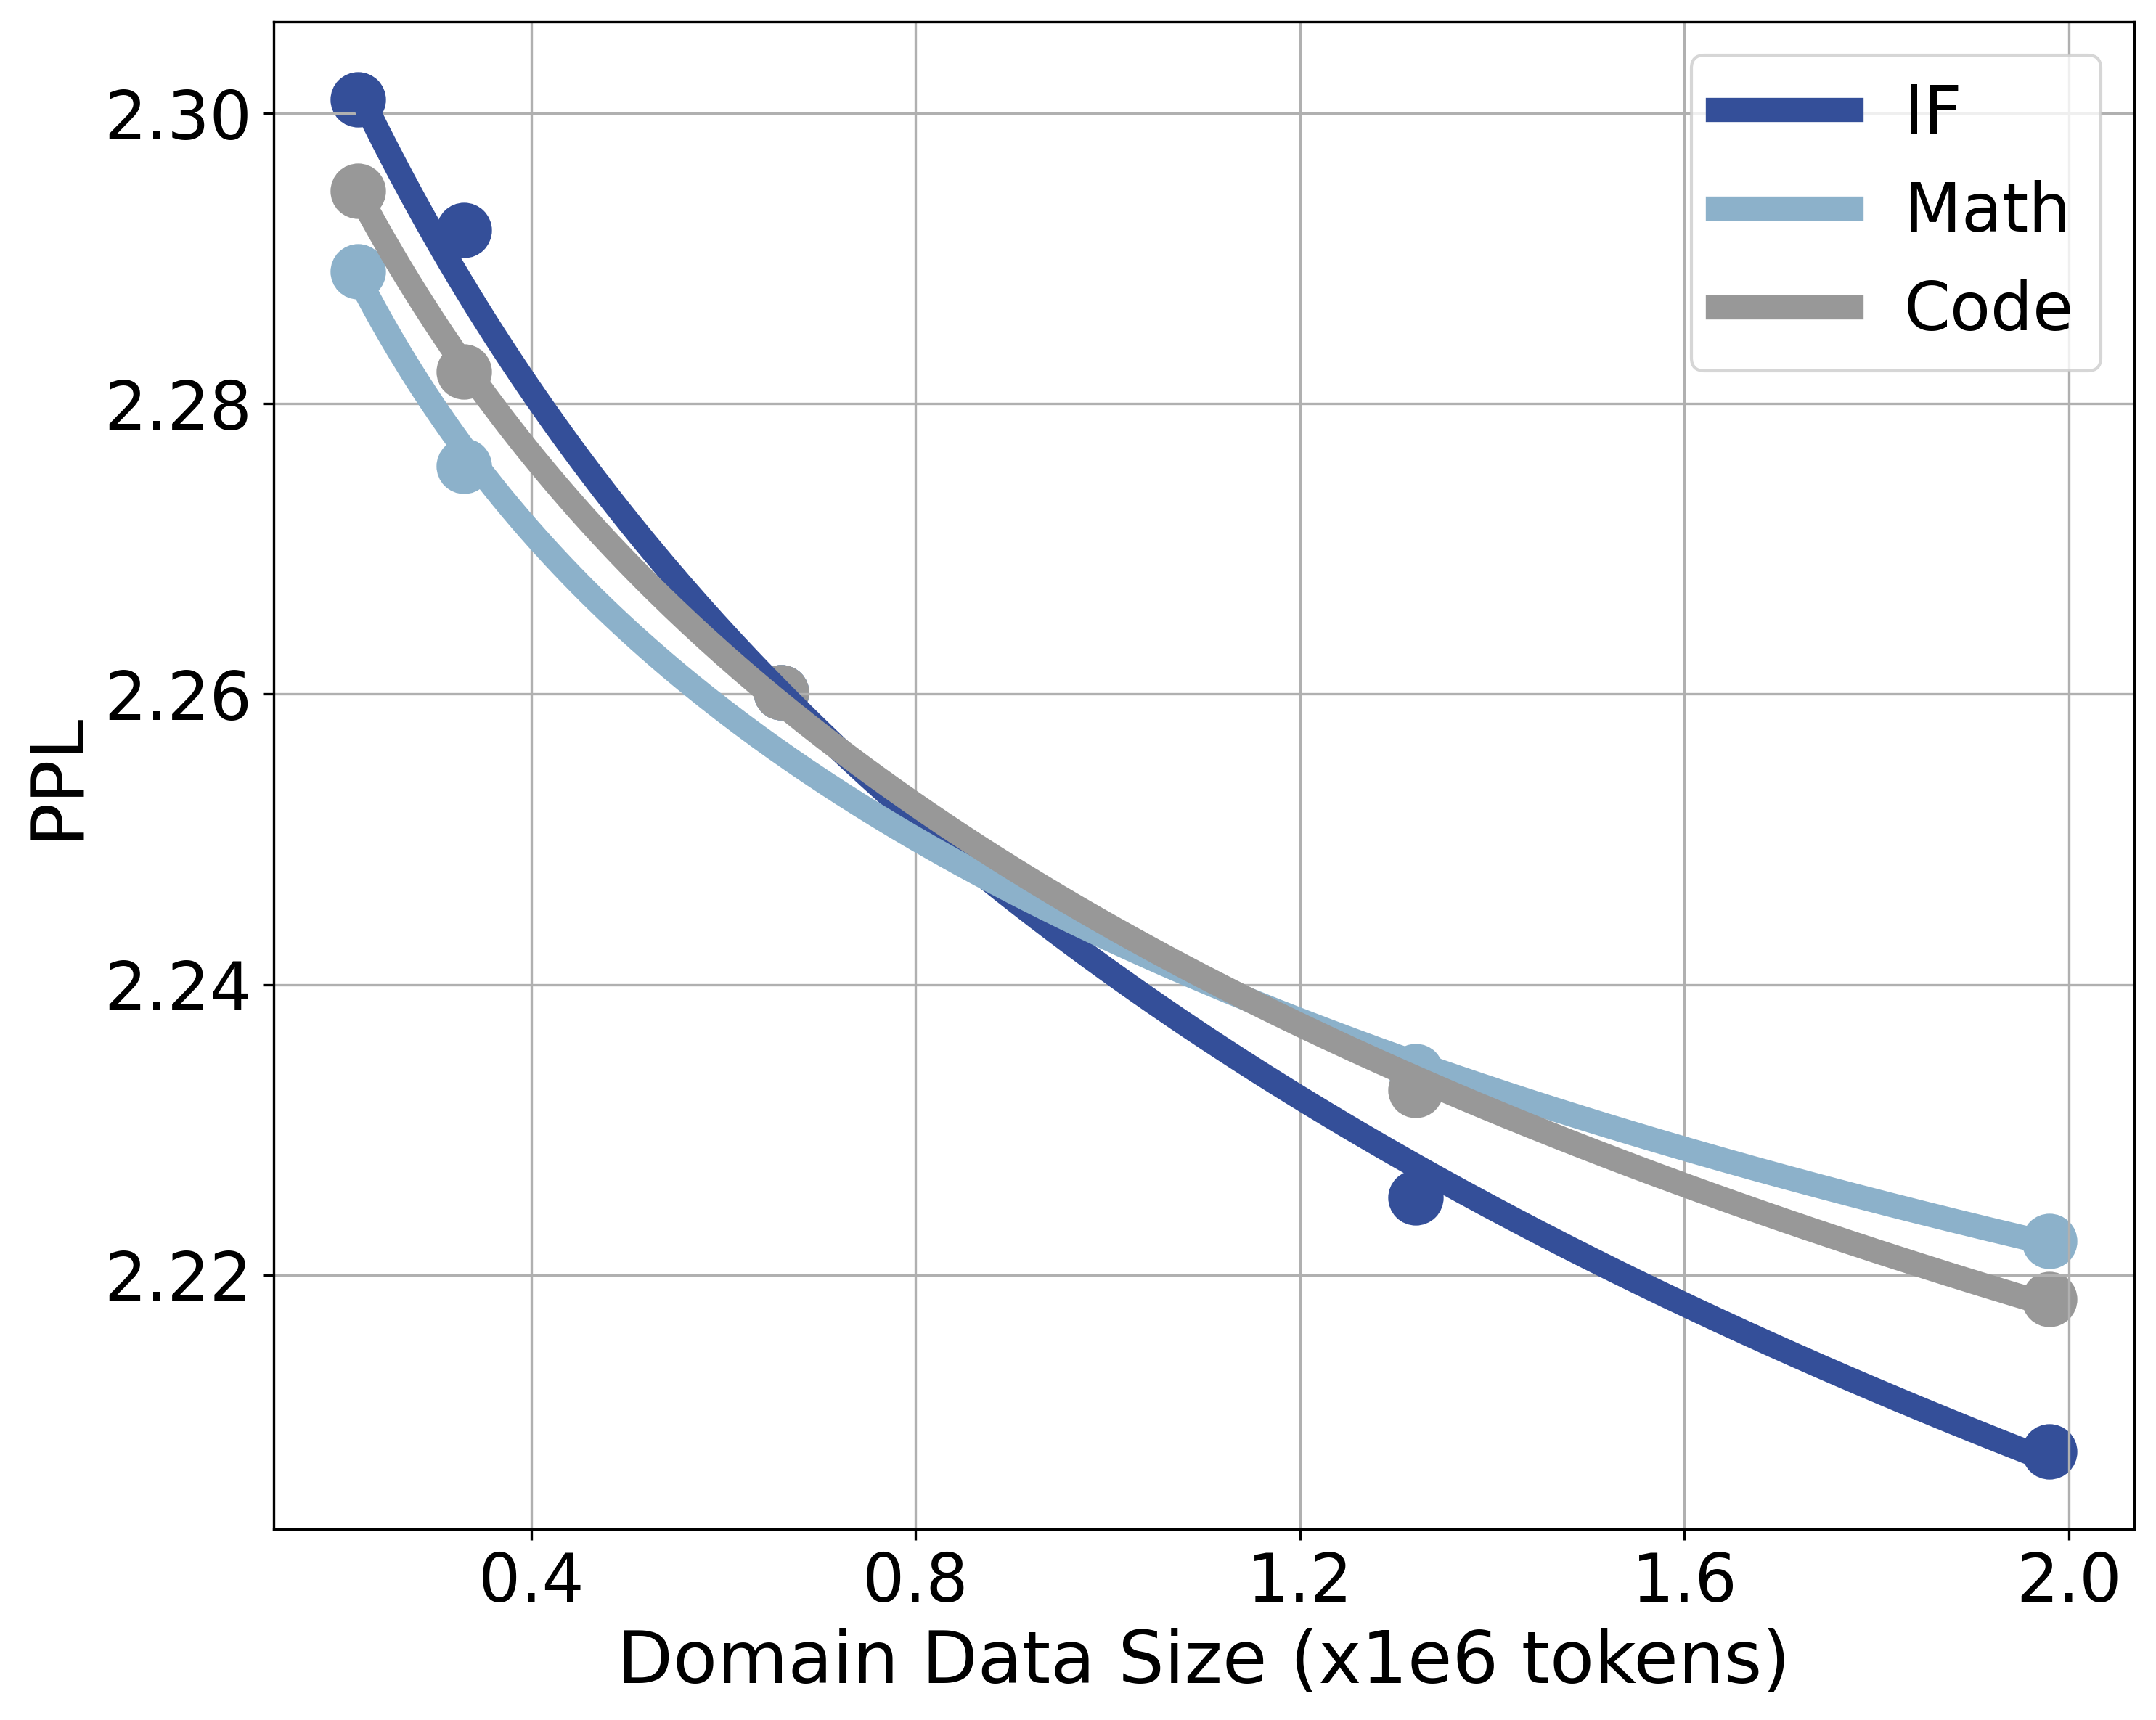

Saved plot to figures/fitted_models.pdf


In [2]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
domain_colors = ["#344F99", "#8CB1CA", "#989898"]

for idx, params in enumerate(optimized_parameters):
    label = domain_labels[idx]
    color = domain_colors[idx]
    x = plot_data["x"][idx]
    y = plot_data["y"][idx]
    x_fine, y_fitted = plot_data["y_fitted"][idx]

    ax.scatter(x, y, color=color, marker="o", s=300)
    ax.plot(x_fine, y_fitted, color=color, linewidth=8, label=label)

ax.tick_params(axis="both", which="major", labelsize=22)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.set_xlabel("Domain Data Size (x1e6 tokens)", fontsize=24)
ax.set_ylabel("PPL", fontsize=24)
ax.legend(fontsize=22)
ax.grid(True)
fig.tight_layout()

output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)
figure_path = output_dir / "fitted_models.pdf"
fig.savefig(figure_path, dpi=300)
plt.show()

print(f"Saved plot to {figure_path}")

